# 4- Trying the models

Classifier: SVM (linear), RF

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
import cognitive_models.interpolate as cwinterp
import cognitive_models.pupil_utils as cwpupil
from importlib import reload
reload(cwpupil)
reload(cwinterp)
reload(cwpre)
reload(cwfeat)

COLET_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "COLET_CSV"
PARTICIPANTS = list(range(1, 48)) # Participants 1 to 10
PARTICIPANTS.remove(6) # Bad data
EXPERIMENTS = [1,2,3,4]

### A. Getting all the needed features

In [3]:
# 1- Load all required data
all_eye_data = cwpre.load_colet_data(COLET_DATASET_DIR, PARTICIPANTS, EXPERIMENTS)

print(f"Loaded eye-tracking data for {len(PARTICIPANTS)} participants and {len(EXPERIMENTS)} experiments. Total records: {len(all_eye_data)}")

There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4099 records at 120 Hz
Final merged and resampled dataset has 2028 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 3437 records at 120 Hz
Final merged and resampled dataset has 1709 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 8754 records at 120 Hz
Final merged and resampled dataset has 4285 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4637 records at 120 Hz
Final merged and resampled dataset has 2290 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 5082 records at 120 Hz
Final merged and resampled dataset has 2505 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 3557 records at 120 Hz
Final merged and resampled dataset has 1769 records at 60 Hz
Ther

In [4]:
# Lets check integrity of the data
all_eye_data.columns
all_eye_data.groupby(['subject_id', 'task_id'])['cl_class'].value_counts().sort_index().head()

subject_id  task_id  cl_class
1           1        low         2028
            2        medium      1709
            3        high        4285
            4        medium      2290
2           1        low         2505
Name: count, dtype: int64

In [5]:
import tqdm

reload(cwfeat)
all_eye_data_grouped = all_eye_data.groupby(['subject_id', 'task_id'])
# Extract all window features
Fs = 60
WINDOW_N = 600 # 5 seconds at 60Hz
WINDOW_STEP = 120
SKIP_EDGE_SAMPLES = Fs # first & last second are discarded

skipped_windows = None
skip_window_counter = 0

features_df = pd.DataFrame()
for (subject_id, task_id), group_df in tqdm.tqdm(all_eye_data_grouped, desc="Extracting features"):
    feature_rows = []
    # Discard edge samples
    group_df = group_df.iloc[SKIP_EDGE_SAMPLES:-SKIP_EDGE_SAMPLES].sort_values('timestamp_sec')
    
    # Extract features in sliding windows
    for start in range(WINDOW_N, len(group_df), WINDOW_STEP):
        window_df = group_df.iloc[start - WINDOW_N:start].reset_index(drop=True)
        window_preprocess_df, window_gaze_df, window_pupil_df, window_gaps_df = cwpre.preprocess_colet_data(window_df, verbose=False)
        if window_preprocess_df['low_confidence_percentage'].iloc[0] > 30:
            t_start = window_preprocess_df['timestamp_sec'].min()
            t_end = window_preprocess_df['timestamp_sec'].max()
            #print(f"Skipping window [{t_start:.2f}, {t_end:.2f}] due to low confidence percentage of {window_preprocess_df['low_confidence_percentage'].iloc[0]:.2f}%")
            skip_window_counter += 1
            window_preprocess_df['skip_id'] = skip_window_counter
            skipped_windows = pd.concat([skipped_windows, window_preprocess_df], ignore_index=True) if skipped_windows is not None else window_preprocess_df
            continue

        # Extract features
        try:
            features = cwfeat.extract_window_features(
                window_preprocess_df, 
                window_gaze_df, 
                window_pupil_df, 
                window_gaps_df, 
                ivt_threshold=45, 
                min_fixation_duration=55, 
                verbose=False
            )
        except Exception as e:
            print(f"Error extracting features for window in subject {subject_id}, task {task_id}: {e}")
            continue
        features['bad_samples_ratio'] = window_preprocess_df['low_confidence_percentage'].mean()
        features['subject_id'] = subject_id
        features['task_id'] = task_id
        features['cl_class'] = window_df['cl_class'].iloc[0] # Class is the same for a given task
        feature_rows.append(features)
    
    features_df = pd.concat([features_df, pd.DataFrame(feature_rows)], ignore_index=True)
    # if subject_id > 5:
    #     break

print(f"Extracted features for {len(features_df)} windows.")
print(f"Skipped {skip_window_counter} windows due to low confidence percentage.")

Extracting features: 100%|██████████| 184/184 [06:09<00:00,  2.01s/it]

Extracted features for 3192 windows.
Skipped 296 windows due to low confidence percentage.


In [6]:
# Check what is the issue with the NaNs
print("Number of windows with NaN values:", features_df.isna().any(axis=1).sum())
features_df[features_df.isna().any(axis=1)].head()

Number of windows with NaN values: 3


,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_skew,fixations_duration_kurt,fixations_duration_std,saccades_count,saccades_peak_velocity_min,saccades_peak_velocity_max,...,saccades_duration_std,blinks_count,blinks_duration_max,blinks_duration_min,pupil_lhipa,pupil_ripa2,bad_samples_ratio,subject_id,task_id,cl_class
712,4,2446.3225,3684.07,416.75,-1.410833,2.153521,1427.817370,3,46.557093,104.208864,...,16.670000,0,0.00,0.00,4.106024,0.001557,8.000000,12,4,high
713,4,2450.4900,3283.99,1233.58,-0.741022,-1.653764,948.775409,3,46.557093,104.208864,...,19.248858,0,0.00,0.00,4.206170,0.001776,8.500000,12,4,high
1753,4,2242.1150,5134.36,83.35,0.574044,-2.278743,2324.912255,3,45.796837,396.547911,...,187.861359,6,283.39,150.03,3.485218,0.009085,6.666667,27,3,high


In [7]:
from sklearn import preprocessing
# z-normalize features
features_df_transformed = features_df.copy()
features_df_transformed.dropna(inplace=True) # Drop rows with NaNs for now
feature_cols = [col for col in features_df.columns if col not in ['subject_id', 'task_id', 'cl_class']]

features_df_transformed.describe()

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_skew,fixations_duration_kurt,fixations_duration_std,saccades_count,saccades_peak_velocity_min,saccades_peak_velocity_max,...,saccades_duration_kurt,saccades_duration_std,blinks_count,blinks_duration_max,blinks_duration_min,pupil_lhipa,pupil_ripa2,bad_samples_ratio,subject_id,task_id
count,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,...,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000
mean,20.411414,442.222804,1718.149561,74.322377,1.921057,4.337901,448.782979,19.658514,51.281849,287.631336,...,4.295539,50.366933,2.011916,111.922662,79.366764,4.472014,0.004250,6.034546,24.790216,2.757918
std,5.720822,189.699280,842.356499,35.526866,0.818298,4.463006,264.536535,5.757629,5.818212,135.267437,...,5.001752,47.731480,2.545788,97.506920,68.056648,0.520421,0.003789,7.013366,13.473645,1.089345
min,5.000000,154.576364,400.080000,50.010000,-0.466921,-2.625565,77.750578,4.000000,45.030536,67.880790,...,-3.333333,6.805499,0.000000,0.000000,0.000000,2.203232,0.000363,0.000000,1.000000,1.000000
25%,16.000000,322.731200,1133.560000,50.010000,1.335334,1.078491,279.806493,16.000000,47.627316,194.126578,...,0.322659,23.747653,0.000000,0.000000,0.000000,4.206170,0.001972,1.000000,13.000000,2.000000
50%,20.000000,397.698571,1533.640000,66.680000,1.801722,3.108900,382.905181,20.000000,49.595746,256.575006,...,3.067534,35.467033,1.000000,116.690000,100.020000,4.558674,0.003365,3.166667,24.000000,3.000000
75%,24.000000,508.925294,2067.080000,83.350000,2.397175,6.451581,532.613781,23.000000,52.975262,369.456303,...,7.022027,57.626665,3.000000,200.040000,116.690000,4.807052,0.005301,8.666667,38.000000,4.000000
max,41.000000,1947.056000,7884.910000,633.460000,5.043240,26.431348,3130.766245,40.000000,99.369781,1000.000000,...,30.276843,593.961686,17.000000,283.390000,283.390000,5.708374,0.043860,30.000000,47.000000,4.000000


In [10]:
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, validation_curve
from sklearn import svm, pipeline

features_df_transformed['labels'] = features_df_transformed['cl_class'].map({'low': 0, 'medium': 1, 'high': 2})

X = features_df_transformed[feature_cols].values
y = features_df_transformed['labels'].values

scaler = preprocessing.StandardScaler()
# scaler = preprocessing.MinMaxScaler()
scaler.fit(X)

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(train_x)}, Test set size: {len(test_x)}")

Training set size: 2551, Test set size: 638


In [47]:
# Let's look at the distribution of classes within subjects
class_distribution = features_df_transformed.groupby('subject_id')['cl_class'].value_counts(normalize=True).unstack(fill_value=0)
class_distribution

cl_class,high,low,medium
subject_id,,,
1,0.423729,0.186441,0.389831
2,0.285714,0.553571,0.160714
3,0.000000,0.666667,0.333333
4,0.891892,0.000000,0.108108
5,0.558559,0.261261,0.180180
7,0.333333,0.333333,0.333333
8,0.000000,0.582090,0.417910
9,0.719298,0.280702,0.000000
10,0.000000,0.272727,0.727273


### Building a reusable pipeline ;)

Since we are testing some overlapping windows, we have to be carefull here with possible data leakgae from training to test sets!

1. Outer loop --> Uses *LOSO* (Leave-One-Subject-Out) for testing performances
2. Inner loop --> Uses *GroupKFold* (by subjects) for validatio and hyperparams testing

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, GroupKFold, LeaveOneGroupOut, cross_validate


def find_best_model(model, param_grid, X, y, subject_ids, task_ids):
    # Build the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', model)
    ])

    # Initialize groupkfold validation
    inner_cv = GroupKFold(n_splits=5)

    inner_groups = [f"{subj}_{task}" for subj, task in zip(subject_ids, task_ids)]

    # Grid Search for hyperparameter tuning
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='balanced_accuracy',
        n_jobs=-1,
    )

    # LOSO
    outer_cv = GroupKFold(n_splits=5)

    results = cross_validate(
        grid,
        X,
        y,
        groups=subject_ids,
        cv=outer_cv,
        scoring='balanced_accuracy',
        return_estimator=True,
        return_train_score=True,
        params={"groups": inner_groups}
    )

    return results

### A. Linear SVC

In [49]:
X = features_df_transformed[feature_cols].values
y = features_df_transformed['labels'].values
subject_ids = features_df_transformed['subject_id'].values
task_ids = features_df_transformed['task_id'].values

results = find_best_model(svm.LinearSVC(), {
    'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0]
}, X, y, subject_ids, task_ids)
print("Best hyperparameters for each fold:")
for i, estimator in enumerate(results['estimator']):
    best_params = estimator.best_params_
    print(f"Fold {i+1}: {best_params}")

Best hyperparameters for each fold:
Fold 1: {'clf__C': 0.01}
Fold 2: {'clf__C': 1.0}
Fold 3: {'clf__C': 0.01}
Fold 4: {'clf__C': 0.1}
Fold 5: {'clf__C': 0.01}


Average Train Score: 0.5596
Best Test Score: 0.4972 for subject id 1


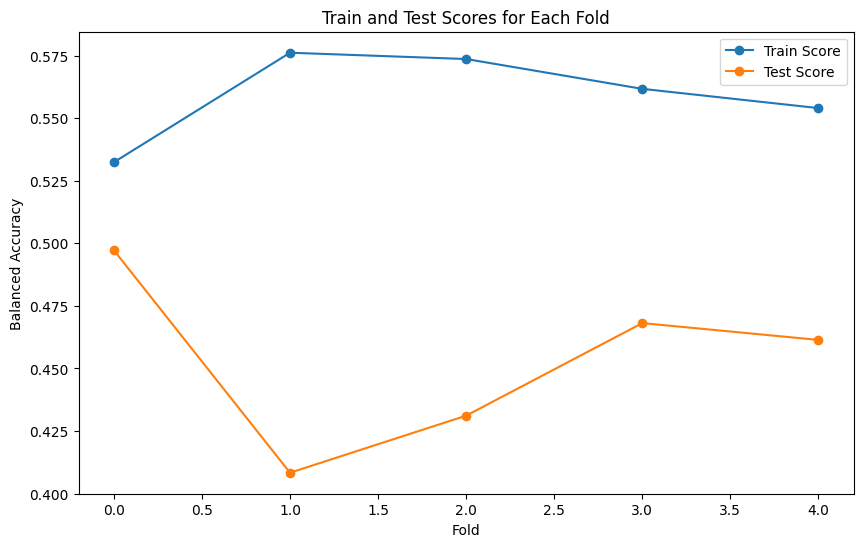

In [53]:
# Plot test train scores for each fold
plt.figure(figsize=(10, 6))
plt.plot(results['train_score'], label='Train Score', marker='o')
plt.plot(results['test_score'], label='Test Score', marker='o')
plt.title('Train and Test Scores for Each Fold')
plt.xlabel('Fold')
plt.ylabel('Balanced Accuracy')
plt.legend()

print(f"Average Train Score: {np.mean(results['train_score']):.4f}")
print(f"Best Test Score: {np.max(results['test_score']):.4f} for subject id {np.argmax(results['test_score']) + 1}")

best_model = results['estimator'][np.argmax(results['test_score'])].best_estimator_


In [55]:
train_acc = best_model.score(train_x, train_y)
train_acc

0.5260682085456684

Cross-Validation with 5 splits, validation samples: 638
Train Accuracy: 0.55, Cross-validation Score: 0.52 (+/- 0.03)


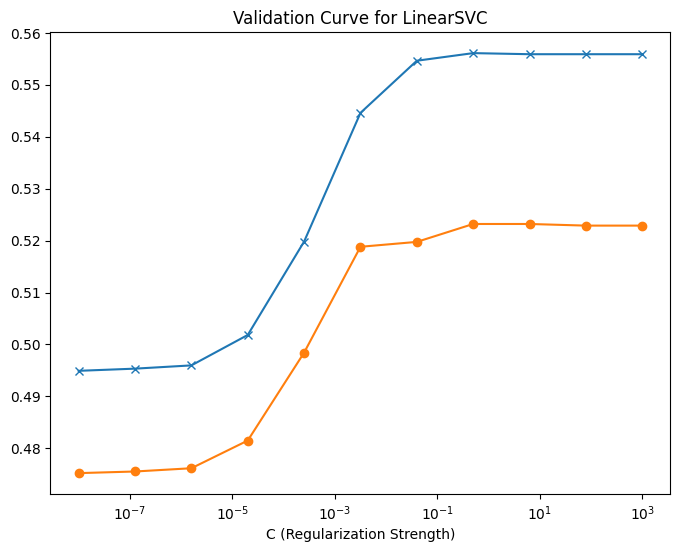

In [ ]:
cv = ShuffleSplit(n_splits=5, test_size=0.25, random_state=42)
print(f"Cross-Validation with {cv.get_n_splits()} splits, validation samples: {cv.test_size * len(train_x):.0f}")

train_x_transformed = scaler.transform(train_x)
model = svm.LinearSVC(class_weight='balanced')
Cs = np.logspace(-8, 3, 11)
train_scores, val_scores = validation_curve(model, train_x_transformed, train_y, param_name="C", param_range=Cs, cv=cv)
plt.figure(figsize=(8, 6))
plt.plot(Cs, train_scores.mean(axis=1), label='Train Score', marker='x')
plt.plot(Cs, val_scores.mean(axis=1), label='Validation Score', marker='o')
plt.xscale('log')
plt.title('Validation Curve for LinearSVC')
plt.xlabel('C (Regularization Strength)')

# Just using C=1 is the best we can achieve
score = cross_val_score(model, train_x_transformed, train_y, cv=cv)
model.fit(train_x_transformed, train_y)
train_acc = model.score(train_x_transformed, train_y)
print(f"Train Accuracy: {train_acc:.2f}, Cross-validation Score: {score.mean():.2f} (+/- {score.std() * 2:.2f})")

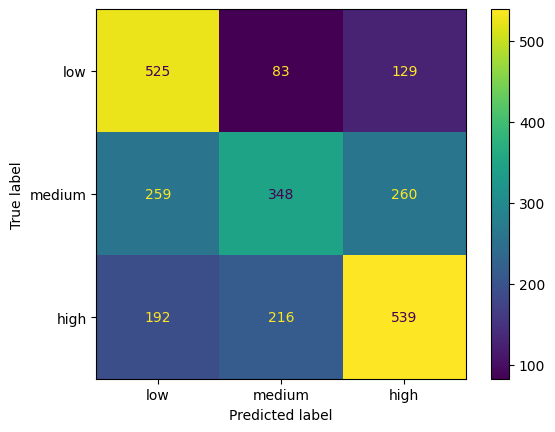

In [ ]:
# Lets show the confusion matrix for the 3 classes (on validation set)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_y_pred = model.predict(train_x_transformed)
cm = confusion_matrix(train_y, val_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'medium', 'high'])
disp.plot()

### B. Random Forest Classifier

Cross-Validation with 10 splits, validation samples: 765
Train Accuracy: 0.99, Cross-validation Score: 0.64 (+/- 0.03)


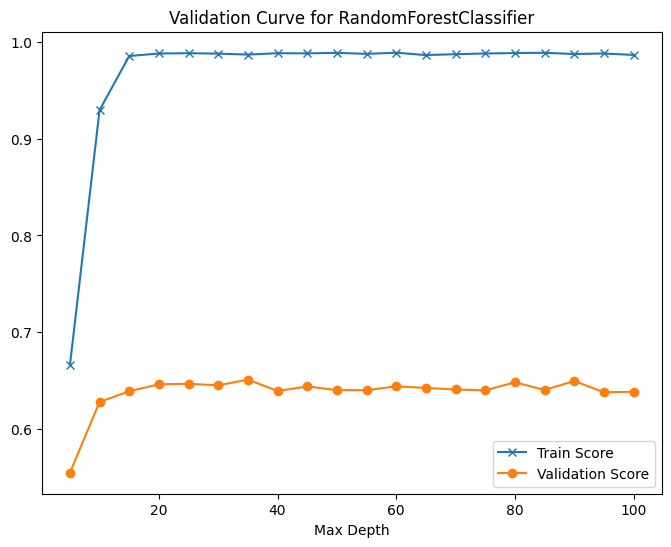

In [20]:
from sklearn import ensemble
cv = ShuffleSplit(n_splits=10, test_size=0.3, random_state=42)
print(f"Cross-Validation with {cv.get_n_splits()} splits, validation samples: {cv.test_size * len(train_x):.0f}")

train_x_transformed = scaler.transform(train_x)
model = ensemble.RandomForestClassifier(class_weight='balanced', n_estimators=10)
# n_trees = np.linspace(1, 100, 20, dtype=int)
max_depths = np.linspace(5, 100, 20, dtype=int)
train_scores, val_scores = validation_curve(model, train_x_transformed, train_y, param_name="max_depth", param_range=max_depths, cv=cv)
plt.figure(figsize=(8, 6))
plt.plot(max_depths, train_scores.mean(axis=1), label='Train Score', marker='x')
plt.plot(max_depths, val_scores.mean(axis=1), label='Validation Score', marker='o')
plt.xscale('linear')
plt.title('Validation Curve for RandomForestClassifier')
plt.xlabel('Max Depth')
plt.legend()

# Just using C=1 is the best we can achieve
score = cross_val_score(model, train_x_transformed, train_y, cv=cv)
model.fit(train_x_transformed, train_y)
train_acc = model.score(train_x_transformed, train_y)
print(f"Train Accuracy: {train_acc:.2f}, Cross-validation Score: {score.mean():.2f} (+/- {score.std() * 2:.2f})")

Test Accuracy: 0.70


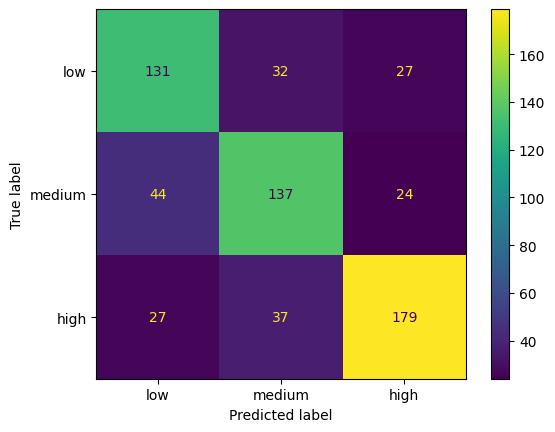

In [21]:
# On the test data (confusion matrix)
test_acc = model.score(scaler.transform(test_x), test_y)
print(f"Test Accuracy: {test_acc:.2f}")
cm = confusion_matrix(test_y, model.predict(scaler.transform(test_x)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'medium', 'high'])
disp.plot()

### C. HGBC

Cross-Validation with 10 splits, validation samples: 765
Train Accuracy: 0.99, Cross-validation Score: 0.78 (+/- 0.05)


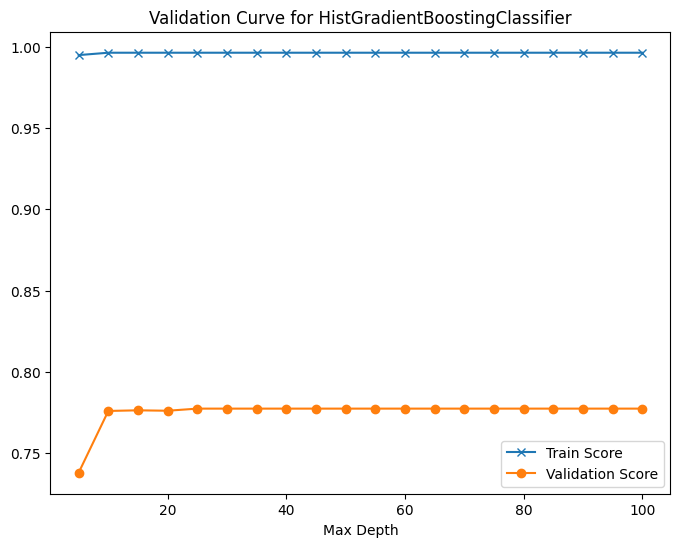

In [24]:
from sklearn.ensemble import HistGradientBoostingClassifier

cv = ShuffleSplit(n_splits=10, test_size=0.3, random_state=42)
print(f"Cross-Validation with {cv.get_n_splits()} splits, validation samples: {cv.test_size * len(train_x):.0f}")

train_x_transformed = scaler.transform(train_x)
model = HistGradientBoostingClassifier(class_weight='balanced')
# n_iters = np.linspace(5, 100, 20, dtype=int)
max_depths = np.linspace(5, 100, 20, dtype=int)
train_scores, val_scores = validation_curve(model, train_x_transformed, train_y, param_name="max_depth", param_range=max_depths, cv=cv)
plt.figure(figsize=(8, 6))
plt.plot(max_depths, train_scores.mean(axis=1), label='Train Score', marker='x')
plt.plot(max_depths, val_scores.mean(axis=1), label='Validation Score', marker='o')
plt.xscale('linear')
plt.title('Validation Curve for HistGradientBoostingClassifier')
plt.xlabel('Max Depth')
plt.legend()

# Just using C=1 is the best we can achieve
score = cross_val_score(model, train_x_transformed, train_y, cv=cv)
model.fit(train_x_transformed, train_y)
train_acc = model.score(train_x_transformed, train_y)
print(f"Train Accuracy: {train_acc:.2f}, Cross-validation Score: {score.mean():.2f} (+/- {score.std() * 2:.2f})")


Test Accuracy: 0.85


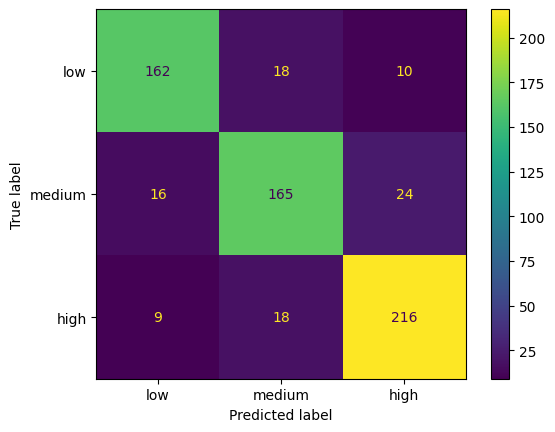

In [25]:
# On the test data (confusion matrix)
test_acc = model.score(scaler.transform(test_x), test_y)
print(f"Test Accuracy: {test_acc:.2f}")
cm = confusion_matrix(test_y, model.predict(scaler.transform(test_x)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'medium', 'high'])
disp.plot()

### D. nuSVC

### E. kNN